# Homework Assignment 1

**Course:** COSC 073 - Computational Photography  
**Term:** Spring 2026  
**Author:** Kasuti Makau

In [40]:
import numpy as np
import scipy, skimage
import matplotlib.pyplot as plt

## 1.1 Implement a Basic Image Processing Pipeline

### 1.1a RAW Image Conversion (5 points)

**Prerequisite:** Install `dcraw` since RAW files cannot be directly read by `skimage`.
```bash
brew install dcraw
```

#### Step 1: Extract RAW metadata
Run this command to get the black, white and scale values:

In [41]:
!dcraw -4 -d -v -W -T data/Thayer.CR2

Loading Canon EOS 2000D image from data/Thayer.CR2 ...
Scaling with darkness 2044, saturation 16383, and
multipliers 2.293742 1.000000 1.368654 1.000000
Building histograms...
Writing data to data/Thayer.tiff ...


**Extracted values:**

| Parameter | Value |
|-----------|-------|
| Black     | 2044  |
| White     | 16383 |
| R Scale   | 2.293742 |
| G Scale   | 1.000000 |
| B Scale   | 1.368654 |

#### Step 2: Generate the correct TIFF file

**Important:** Delete the `.tiff` file created in Step 1, then run dcraw with different flags:

> **Note:** The `-D` flag (uppercase) outputs the raw sensor data without any processing, while `-d` (lowercase) applies basic scaling. We need the unprocessed data for our pipeline.

In [42]:
!rm data/Thayer.tiff 

In [43]:
!dcraw -4 -D -T data/Thayer.CR2

## 1.1b Python Initials (5 points)
Using [`skimage.io.imread`](https://scikit-image.org/docs/stable/api/skimage.io.html#skimage.io.imread) to load the image as a numpy array, then
  [`ndarray.astype`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.astype.html) to convert to double precision.

In [44]:
from skimage.io import imread

img = imread('data/Thayer.tiff')

bits = img.dtype.itemsize * 8
height, width = img.shape
img_double = img.astype('float64')

print(f'{bits} bits per channel')
print(f'{width} x {height} pixels')
print(f'dtype (double): {img_double.dtype}')

16 bits per channel
6020 x 4016 pixels
dtype (double): float64


## 1.1c Linearization
The raw sensor data has a black level offset and a saturation ceiling. Only 14 of the 16 bits carry meaningful data. 

Using values extracted from `dcraw`:
- **Black level:** 2044
- **White:** 16383

Linear transform `(img - black) / (white - black)` then clip to [0, 1]

In [45]:
black = 2044
white = 16383

img_linear = (img_double - black) / (white - black)
img_linear = img_linear.clip(0, 1)

print(f'black level: {black}')
print(f'white level: {white}')
print(f'min pixel value: {img_double.min()}') # 255 < 2044, so the black level is above the minimum pixel value
print(f'max pixel value: {img_double.max()}')
print(f'min linear value: {img_linear.min()}') 
print(f'max linear value: {img_linear.max()}') # 0.9248 which is less than 1, so the white level is above the maximum pixel value

black level: 2044
white level: 16383
min pixel value: 255.0
max pixel value: 15305.0
min linear value: 0.0
max linear value: 0.9248204198340191


## 1.1d Identifying the Bayer pattern
ltsThe 4 candidate patterns define which pixels in the top-left 2 x 2 block are RGB
We will subsample img_linear for each pattern, apply dcraw WB multipliers as a visual aid and inspect a crop. The correct pattern shows natural colors

![patterns](screenshots/figure2.png)

In [46]:
# import matplotlib.pyplot as plt # moved this import to the top of the file

# scaling factors from step 1 (extract raw metadata)
r_scale, g_scale, b_scale = 2.293742, 1.000000, 1.368654

# patterns from left to right: grbg, rggb, bggr, gbrg
patterns = {
    'grbg': ((0,1), (0,0), (1,1), (1,0)),
    'rggb': ((0,0), (0,1), (1,0), (1,1)),
    'bggr': ((1,1), (0,1), (1,0), (0,0)),
    'gbrg': ((1,0), (0,0), (1,1), (0,1)),
}

for pattern in patterns:
    r_pos, g1_pos, g2_pos, b_pos = patterns[pattern]
    img_r = img_linear[r_pos[0]::2, r_pos[1]::2] * r_scale
    img_g1 = img_linear[g1_pos[0]::2, g1_pos[1]::2] * g_scale
    img_g2 = img_linear[g2_pos[0]::2, g2_pos[1]::2] * g_scale
    img_b = img_linear[b_pos[0]::2, b_pos[1]::2] * b_scale

    print(f'Pattern: {pattern}')
    print(f'R channel: min={img_r.min()}, max={img_r.max()}')
    print(f'G1 channel: min={img_g1.min()}, max={img_g1.max()}')
    print(f'G2 channel: min={img_g2.min()}, max={img_g2.max()}')
    print(f'B channel: min={img_b.min()}, max={img_b.max()}')



## Tried this approach but can't really tell which pattern is correct because the min and max values are all very similar
## The differences in the min and max values are likely due to the different scaling factors applied to each channel,
# but they don't provide a clear indication of which pattern is correct.


Pattern: grbg
R channel: min=0.0, max=2.121139474161378
G1 channel: min=0.0, max=0.9248204198340191
G2 channel: min=0.0, max=0.9246809400934515
B channel: min=0.0, max=1.2654728176302392
Pattern: rggb
R channel: min=0.0, max=2.1212994394309224
G1 channel: min=0.0, max=0.9247506799637353
G2 channel: min=0.0, max=0.9246112002231676
B channel: min=0.0, max=1.2655682673826627
Pattern: bggr
R channel: min=0.0, max=2.1209795088918337
G1 channel: min=0.0, max=0.9247506799637353
G2 channel: min=0.0, max=0.9246112002231676
B channel: min=0.0, max=1.2657591668875097
Pattern: gbrg
R channel: min=0.0, max=2.120819543622289
G1 channel: min=0.0, max=0.9248204198340191
G2 channel: min=0.0, max=0.9246809400934515
B channel: min=0.0, max=1.2656637171350862


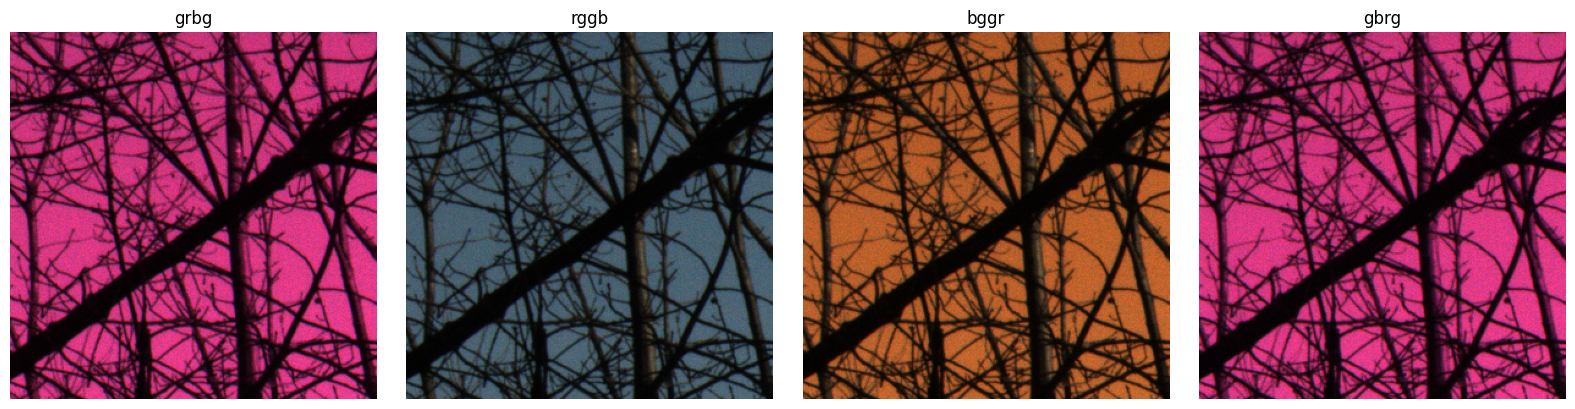

Chosen pattern: rggb


In [ ]:
# scaling factors from step 1 (extract raw metadata)
r_scale, g_scale, b_scale = 2.293742, 1.000000, 1.368654

# (row, col) positions in each 2x2 Bayer tile
patterns = {
    'grbg': {'R': (0,1), 'G1': (0,0), 'G2': (1,1), 'B': (1,0)},
    'rggb': {'R': (0,0), 'G1': (0,1), 'G2': (1,0), 'B': (1,1)},
    'bggr': {'R': (1,1), 'G1': (0,1), 'G2': (1,0), 'B': (0,0)},
    'gbrg': {'R': (1,0), 'G1': (0,0), 'G2': (1,1), 'B': (0,1)},
}

rgb_results = {}

for name, pattern in patterns.items():
    R = img_linear[pattern['R'][0]::2, pattern['R'][1]::2] * r_scale
    G1 = img_linear[pattern['G1'][0]::2, pattern['G1'][1]::2]
    G2 = img_linear[pattern['G2'][0]::2, pattern['G2'][1]::2]
    G = ((G1 + G2) / 2) * g_scale
    B = img_linear[pattern['B'][0]::2, pattern['B'][1]::2] * b_scale

    rgb_results[name] = np.stack([R, G, B], axis=-1).clip(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, ['grbg', 'rggb', 'bggr', 'gbrg']):
    ax.imshow(rgb_results[name][:300, :300])
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Chosen pattern: rggb")